# 03 — Shapelet Analysis and Interpretability

A **shapelet** is a short subsequence that tends to appear in one class and not
the other. Unlike a whole-series classifier such as DTW k-NN, a shapelet gives
a rule you can read out loud: *"if this 40-step pattern appears anywhere in a
child's activity trace, they fall on this side of the split."*

This notebook works through the classic discrete shapelet search step by step —
the distance function, the split criterion, the two standard speedups, and
finally the rule the winner encodes.

Equivalent to: `python main.py --stage shapelets`

In [1]:
# Make the project's src/ package importable from inside notebooks/.
import os
import sys
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

from src.shapelets import (compare_with_random_shapelets, evaluate_shapelets,
                           extract_candidate_shapelets, extract_rule,
                           plot_shapelet_alignment, print_leaderboard,
                           subsequence_dist_euclidean)
from src.utils import load_prepared_arrays, select_model_channels

## 1. Load the two modelled channels

Only `enmo` (movement intensity) and `anglez` (wrist posture) are used. The raw
X/Y/Z axes are excluded because of naming inconsistencies in the source data,
and light/battery carry no behavioural signal.

The arrays are transposed to `(subjects, channels, timesteps)`, which is the
layout every time-series library expects.

In [2]:
X_train_raw, X_test_raw, y_train, y_test = load_prepared_arrays()

X_train = select_model_channels(X_train_raw)
X_test = select_model_channels(X_test_raw)

print(f"Train set shape: {X_train.shape} (Subjects, Channels, Timesteps)")
print(f"Test set shape:  {X_test.shape}")
print(f"Training labels: {y_train.shape} (Binary: 0=Healthy, 1=Impaired)")

Train set shape: (3549, 2, 200) (Subjects, Channels, Timesteps)
Test set shape:  (888, 2, 200)
Training labels: (3549,) (Binary: 0=Healthy, 1=Impaired)


## 2. The candidate pool

Fifteen subsequences cut from training subjects, deliberately spanning three
lengths (20, 30, 40) and both channels, so the leaderboard can show which
combination discriminates best. The exact coordinates live in
`config.SHAPELET_CANDIDATES`.

Each candidate is stored twice: raw values, for plotting a recognisable shape,
and Z-normalised values, which is what the distance functions actually consume.

In [3]:
shapelets = extract_candidate_shapelets(X_train, y_train)

Extracted 15 candidate shapelets from training data.


## 3. Local subsequence alignment

A shapelet $S$ is aligned with a target series $T$ by sliding it across every
subsequence of $T$ of the same length and keeping the closest match:

$$\text{subsequenceDist}(T, S) = \min_{S' \in S_T^{|S|}} \text{Dist}(S, S')$$

where $S_T^{|S|}$ is the set of all subsequences of $T$ of length $|S|$. This
buys two invariances:

1. **Phase shift invariance** — the pattern is found wherever in time it
   occurs, because every alignment is tried.
2. **Amplitude invariance** — if both $S$ and each window $S'$ are Z-normalised
   before comparison, the distance reflects *shape* rather than absolute scale.

The demo below uses the plain (un-normalised) Euclidean version, which is the
clearest statement of the definition. Everything after this point uses the
Z-normalised version, so the results respond to shape alone.

In [4]:
distance, match_index = subsequence_dist_euclidean(X_train[0, 0],
                                                   shapelets[0]["values"])

print("Subject 0 - Subsequence alignment with Shapelet 0:")
print(f"  Best match start index: {match_index}")
print(f"  Minimum Euclidean Distance: {distance:.4f}")

Subject 0 - Subsequence alignment with Shapelet 0:
  Best match start index: 146
  Minimum Euclidean Distance: 2.0274


## 4. Scoring a shapelet: information gain

Sort the subjects by their distance to the shapelet, then treat the distance
axis as a decision boundary. A split point $sp$ divides the data into
$D_1$ (distance $\le sp$) and $D_2$ (distance $> sp$):

1. **Baseline entropy** of the full set $D$:
   $$I(D) = -p(0)\log_2 p(0) - p(1)\log_2 p(1)$$
2. **Weighted split entropy:**
   $$\hat{I}(D) = \frac{|D_1|}{|D|} I(D_1) + \frac{|D_2|}{|D|} I(D_2)$$
3. **Information gain:**
   $$\text{Gain}(sp) = I(D) - \hat{I}(D)$$

`find_best_split` scores every boundary between two distinct distances and
keeps the best. The whole sweep is vectorised with cumulative sums, so all
$N-1$ candidate boundaries are evaluated in one pass.

## 5. The search, with two speedups

Both are classic and both are *admissible* — they never change which shapelet
wins, only how long it takes to find out.

1. **Distance early abandon.** While accumulating a window's squared distance,
   stop the moment it exceeds the best distance found so far in this series:
   that window cannot win, so the remaining terms are wasted work.

2. **Admissible entropy pruning.** Having scored only part of the training set,
   ask how high the gain could possibly get if every remaining subject fell in
   the most flattering place. Because entropy is convex, that optimum sits at
   one of four corners. If even that ceiling is below the best gain already
   achieved, the candidate is abandoned.

   A 20% guard window runs first, then the bound is re-checked every 10% — so
   no candidate is discarded on the strength of a handful of samples.

Subjects are scanned in a fixed shuffled order (seeded). That matters: scanning
in dataset order would let a run of same-class subjects at the start make the
bound wildly optimistic or pessimistic.

In [5]:
results = evaluate_shapelets(shapelets, X_train, y_train)

Evaluating 15 candidate shapelets...
  Shapelet  0 | Channel 0 | Length 30 | Gain: 0.001226 | Split: 5.7350 | Pruned: False (at 3549)
  Shapelet  1 | Channel 1 | Length 30 | Gain: 0.001488 | Split: 5.6985 | Pruned: False (at 3549)
  Shapelet  2 | Channel 0 | Length 20 | Gain: 0.001550 | Split: 2.5691 | Pruned: False (at 3549)
  Shapelet  3 | Channel 1 | Length 20 | Gain: 0.000642 | Split: 4.0575 | Pruned: False (at 3549)
  Shapelet  4 | Channel 0 | Length 40 | Gain: 0.001346 | Split: 6.2174 | Pruned: False (at 3549)
  Shapelet  5 | Channel 1 | Length 40 | Gain: 0.002661 | Split: 7.1975 | Pruned: False (at 3549)
  Shapelet  6 | Channel 0 | Length 30 | Gain: 0.000000 | Split: 0.0000 | Pruned: True  (at 3540)
  Shapelet  7 | Channel 1 | Length 30 | Gain: 0.000000 | Split: 0.0000 | Pruned: True  (at 3540)
  Shapelet  8 | Channel 0 | Length 20 | Gain: 0.000000 | Split: 0.0000 | Pruned: True  (at 3540)
  Shapelet  9 | Channel 1 | Length 20 | Gain: 0.001787 | Split: 4.9484 | Pruned: False (at

## 6. Leaderboard and speedup audit

The audit compares the operations actually performed against the brute-force
count, computed analytically as
`n_subjects x (n_timesteps - L + 1) x L`.

In [6]:
ranked = print_leaderboard(results)


=== RANKED LEADERBOARD OF SHAPELETS ===
Rank |   ID |  Info Gain | Split Thresh | Channel | Length
----------------------------------------------------------
   1 |   10 |   0.003205 |       4.4712 |       0 |     40
   2 |    5 |   0.002661 |       7.1975 |       1 |     40
   3 |    9 |   0.001787 |       4.9484 |       1 |     20
   4 |    2 |   0.001550 |       2.5691 |       0 |     20
   5 |    1 |   0.001488 |       5.6985 |       1 |     30
   6 |    4 |   0.001346 |       6.2174 |       0 |     40
   7 |    0 |   0.001226 |       5.7350 |       0 |     30
   8 |    3 |   0.000642 |       4.0575 |       1 |     20
   9 |    6 |   0.000000 |       0.0000 |       0 |     30
  10 |    7 |   0.000000 |       0.0000 |       1 |     30
  11 |    8 |   0.000000 |       0.0000 |       0 |     20
  12 |   11 |   0.000000 |       0.0000 |       1 |     40
  13 |   12 |   0.000000 |       0.0000 |       0 |     30
  14 |   13 |   0.000000 |       0.0000 |       0 |     30
  15 |   14 |  

## 7. Comparison with alternative strategies

**Random extraction.** Instead of evaluating a chosen pool, draw $K=20$
subsequences at random and score them the same way. This is a negative control:
if random cuts match a deliberately chosen pool, the pool is not carrying
information. Note the absolute gains throughout — all well under 0.01 bits,
which says plainly that no single shapelet separates these classes.

**Gradient-based learning** (Grabocka et al., 2014) is the alternative not run
here. It replaces the non-differentiable $\min$ with a soft-min distance:

$$M(T, S) = \frac{\sum_i d(T_i, S)\, e^{-\alpha d(T_i, S)}}
{\sum_i e^{-\alpha d(T_i, S)}}$$

which makes the whole objective differentiable, so shapelet values can be
learned by gradient descent:

$$S \leftarrow S - \eta \frac{\partial L(y, \hat{y})}{\partial S}$$

The learned shapelet need not match any real subsequence, and the discrete
candidate search disappears entirely. `RDSTClassifier` in notebook 04 is the
closest thing run in this project.

In [7]:
random_gains = compare_with_random_shapelets(X_train, y_train,
                                             ranked[0]["gain"])

=== Random Shapelets (K=20) vs Discrete Pool ===
  Random Shapelets Max Gain:  0.005818
  Random Shapelets Mean Gain: 0.001933
  Our Pool Best Shapelet Gain: 0.003205


## 8. The rule, and where it matches

The top-ranked shapelet becomes an if/else rule: subjects closer to it than its
threshold get the class of the subject it was cut from, everyone else gets the
other class.

The figure shows where it matches in four example subjects, two from each
class. Raw values are drawn so the shape stays recognisable; only the match
location and the reported distance come from the Z-normalised metric.

=== Factual Classification Rule ===
If Time Series Q contains a subsequence within a distance threshold of 4.4712 matching Shapelet 10, then classify as Problematic (Class 1); else Non-Problematic (Class 0).


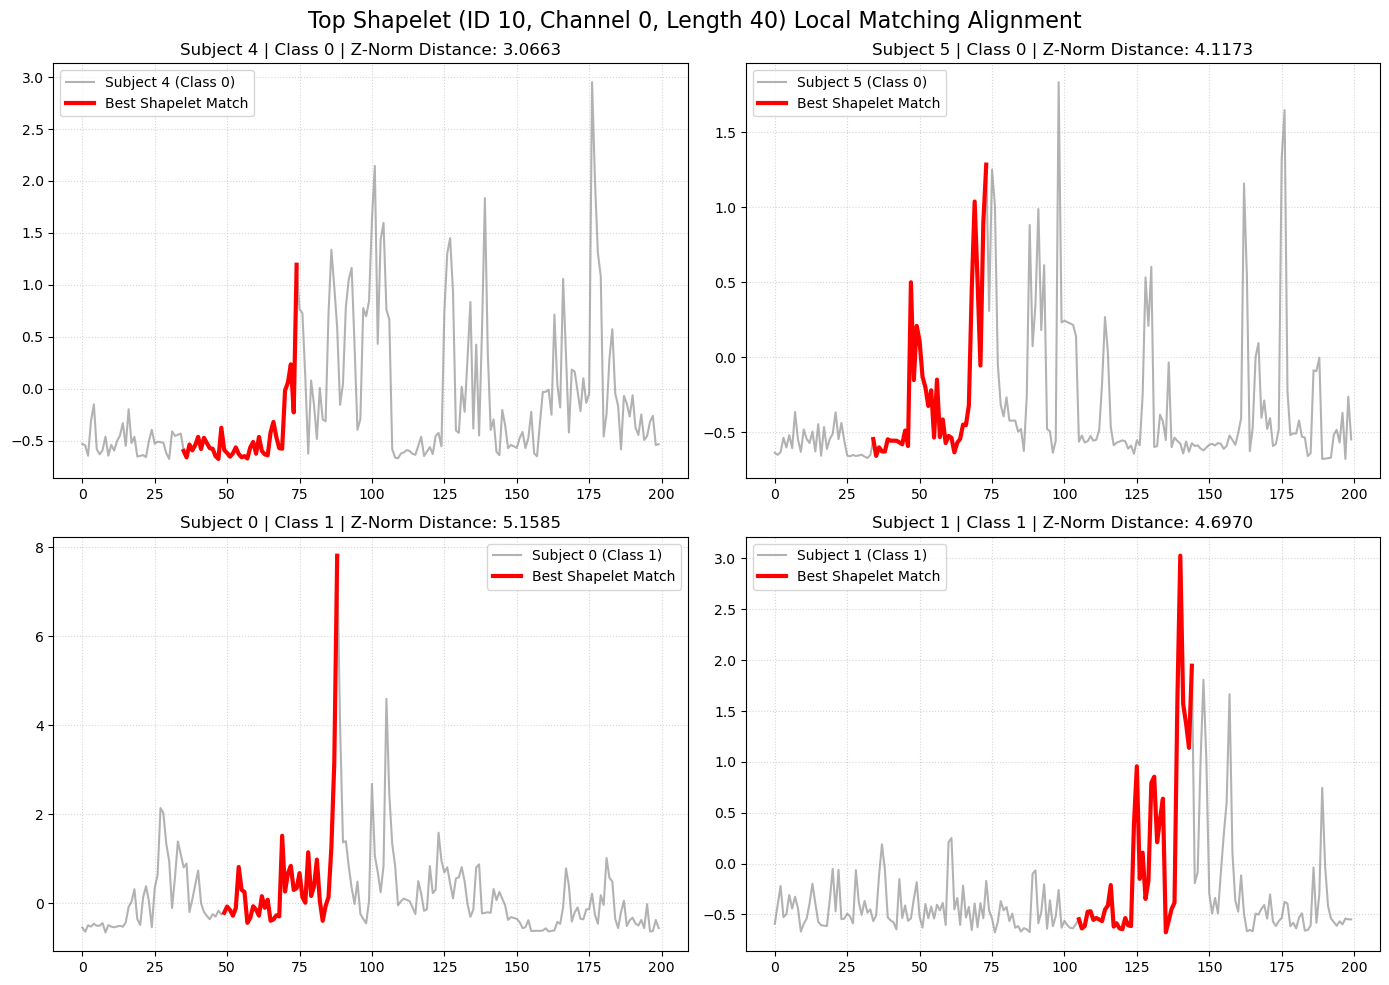

In [8]:
best_result, best_shapelet = extract_rule(ranked, shapelets)

plot_shapelet_alignment(best_result, best_shapelet, X_train, y_train)

## What to take from this

The information gains are tiny — the best is around 0.003 bits out of a
possible 1.0. A single local pattern does not separate problematic from
non-problematic internet use in this data, and the honest reading of the
leaderboard is that shapelets alone are not a viable classifier here.

That is a useful result rather than a failed one: it motivates the ensemble
methods in notebook 04, which combine thousands of weak local features instead
of relying on one.